# ClonalOrigin sequential model and its summary statistics for SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from ClonalOrigin_seq_sim import ClonalOrigin_seq_sim
from homoplasy_index import homoplasy_index
from G4_test import G4_test
from LD_r import LD_r

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load genome data and clonal tree.

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(10, 100000)

In [4]:
np.random.seed(100)
clonal_tree = ClonalTree(n=10)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                   _______ 2
                                        __________________________|
                            ___________|                          |_______ 8
                           |           |
                           |           |___________________________________ 1
                           |
                        ___|                         _____________________ 6
                       |   |                       ,|
                       |   |                       ||  ___________________ 3
                       |   |                       ||_|
                       |   |_______________________|  |___________________ 9
  _____________________|                           |
 |                     |                           |         _____________ 5
 |                     |                           |________|
_|                     |                                    |_____________ 7
 |                  

## Summary statistics

This notebook evaluates the proportions and exact values of LD and G4 for comparison and selection. The items used in the summary statistics is listed below. Let $d$ denote the distance between sites in a pair, and $L$ denote the length of the gene segment.

1. $\text{LD}_{d < L/2}$

2. $\text{LD}_{d \geq L/2}$

3. $\# \text{G4}_{d < L/2}$

4. $\# \text{G4}_{d \geq L/2}$

5. $\frac{\text{LD}_{d < L/2}}{\# \text{segregating pairs that } d < L/2}$

6. $\frac{\text{LD}_{d \geq L/2}}{\# \text{segregating pairs that } d \geq L/2}$

7. $\frac{\# \text{G4}_{d < L/2}}{\# \text{segregating pairs that } d < L/2}$

8. $\frac{\# \text{G4}_{d \geq L/2}}{\# \text{segregating pairs that } d \geq L/2}$

9. $\text{LD}_{20 \leq d < 50}$

10. $\text{LD}_{50 \leq d \leq 80}$

11. $\# \text{G4}_{20 \leq d < 50}$

12. $\# \text{G4}_{50 \leq d \leq 80}$

13. $\frac{\text{LD}_{20 \leq d < 50}}{\# \text{segregating pairs that } 20 \leq d < 50}$

14. $\frac{\text{LD}_{50 \leq d \leq 80}}{\# \text{segregating pairs that } 50 \leq d \leq 80}$

15. $\frac{\# \text{G4}_{20 \leq d < 50}}{\# \text{segregating pairs that } 20 \leq d < 50}$

16. $\frac{\# \text{G4}_{50 \leq d \leq 80}}{\# \text{segregating pairs that } 50 \leq d \leq 80}$

17. homoplasy index based on the clonal structure

18. Proportion of segregating sites

19. L

### Get summary statistics from SimBac data

In [6]:
x_500_mat = np.loadtxt("../data/x_500_mat.csv", delimiter=",")
x_2000_mat = np.loadtxt("../data/x_2000_mat.csv", delimiter=",")
x_6000_mat = np.loadtxt("../data/x_6000_mat.csv", delimiter=",")

x_500_mat, x_2000_mat, x_6000_mat

(array([[4.89236910e+02, 7.90911321e+01, 2.43000000e+02, ...,
         3.47457627e-01, 1.54000000e-01, 5.00000000e+02],
        [1.30225234e+02, 3.84706318e+01, 4.10000000e+01, ...,
         1.89655172e-01, 9.40000000e-02, 5.00000000e+02],
        [1.64287108e+02, 5.46259369e+01, 4.20000000e+01, ...,
         3.04878049e-01, 1.14000000e-01, 5.00000000e+02],
        ...,
        [1.32257964e+02, 3.64943389e+01, 4.10000000e+01, ...,
         2.31884058e-01, 1.06000000e-01, 5.00000000e+02],
        [3.35915497e+02, 1.16553832e+02, 4.57000000e+02, ...,
         5.00000000e-01, 1.52000000e-01, 5.00000000e+02],
        [1.34897042e+02, 3.05163966e+01, 6.10000000e+01, ...,
         4.09638554e-01, 9.80000000e-02, 5.00000000e+02]], shape=(100, 19)),
 array([[4.35220020e+03, 1.06134787e+03, 3.32700000e+03, ...,
         4.00809717e-01, 1.48000000e-01, 2.00000000e+03],
        [2.98704881e+03, 9.31960893e+02, 2.64000000e+03, ...,
         4.29928741e-01, 1.20000000e-01, 2.00000000e+03],
        

In [7]:
x_o_500 = torch.tensor(x_500_mat[0, :], device=torch_device)
x_o_500 = x_o_500.to(torch.float32)

x_o_2000 = torch.tensor(x_2000_mat[0, :], device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)

x_o_6000 = torch.tensor(x_6000_mat[0, :], device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)

In [8]:
x_o_500.shape, x_o_2000.shape, x_o_6000.shape, x_o_500.dtype, x_o_2000.dtype, x_o_6000.dtype

(torch.Size([19]),
 torch.Size([19]),
 torch.Size([19]),
 torch.float32,
 torch.float32,
 torch.float32)

### Load simulations from ClonalOrigin model

In [16]:
x_o_ClonalOrigin = np.loadtxt("../data/x_o_ClonalOrigin.csv", delimiter=",")
x_o_ClonalOrigin

array([[9.96053871e+01, 1.41681548e+01, 1.90000000e+01, 2.00000000e+00,
        2.00413254e-01, 1.06527479e-01, 3.82293763e-02, 1.50375940e-02,
        2.08164407e+01, 1.44164541e+01, 4.00000000e+00, 4.00000000e+00,
        2.81303253e-01, 2.21791601e-01, 5.40540541e-02, 6.15384615e-02,
        2.50000000e-01, 7.20000000e-02, 5.00000000e+02],
       [6.13090598e+03, 1.15079756e+03, 5.28100000e+03, 2.48800000e+03,
        1.54899090e-01, 1.00418635e-01, 1.33425973e-01, 2.17102967e-01,
        3.98083919e+02, 3.23600268e+02, 7.00000000e+01, 1.07000000e+02,
        2.60696738e-01, 2.09044101e-01, 4.58415193e-02, 6.91214470e-02,
        4.71074380e-01, 1.60000000e-01, 2.00000000e+03],
       [4.68535740e+04, 1.13617077e+04, 3.41510000e+04, 1.52410000e+04,
        1.37660491e-01, 1.12521121e-01, 1.00339057e-01, 1.50939846e-01,
        1.31776996e+03, 1.13266470e+03, 1.30000000e+02, 2.32000000e+02,
        2.81755391e-01, 2.49540582e-01, 2.77955955e-02, 5.11125799e-02,
        3.31911869e-01

In [17]:
CO_x_500 = torch.tensor(x_o_ClonalOrigin[0, :], device=torch_device)
CO_x_500 = CO_x_500.to(torch.float32)

CO_x_2000 = torch.tensor(x_o_ClonalOrigin[1, :], device=torch_device)
CO_x_2000 = CO_x_2000.to(torch.float32)

CO_x_6000 = torch.tensor(x_o_ClonalOrigin[2, :], device=torch_device)
CO_x_6000 = CO_x_6000.to(torch.float32)

CO_x_500, CO_x_2000, CO_x_6000

(tensor([9.9605e+01, 1.4168e+01, 1.9000e+01, 2.0000e+00, 2.0041e-01, 1.0653e-01,
         3.8229e-02, 1.5038e-02, 2.0816e+01, 1.4416e+01, 4.0000e+00, 4.0000e+00,
         2.8130e-01, 2.2179e-01, 5.4054e-02, 6.1538e-02, 2.5000e-01, 7.2000e-02,
         5.0000e+02]),
 tensor([6.1309e+03, 1.1508e+03, 5.2810e+03, 2.4880e+03, 1.5490e-01, 1.0042e-01,
         1.3343e-01, 2.1710e-01, 3.9808e+02, 3.2360e+02, 7.0000e+01, 1.0700e+02,
         2.6070e-01, 2.0904e-01, 4.5842e-02, 6.9121e-02, 4.7107e-01, 1.6000e-01,
         2.0000e+03]),
 tensor([4.6854e+04, 1.1362e+04, 3.4151e+04, 1.5241e+04, 1.3766e-01, 1.1252e-01,
         1.0034e-01, 1.5094e-01, 1.3178e+03, 1.1327e+03, 1.3000e+02, 2.3200e+02,
         2.8176e-01, 2.4954e-01, 2.7796e-02, 5.1113e-02, 3.3191e-01, 1.5667e-01,
         6.0000e+03]))

In [18]:
CO_x_500.shape, CO_x_2000.shape, CO_x_6000.shape, CO_x_500.dtype, CO_x_2000.dtype, CO_x_6000.dtype

(torch.Size([19]),
 torch.Size([19]),
 torch.Size([19]),
 torch.float32,
 torch.float32,
 torch.float32)

In [9]:
theta1 = np.loadtxt('../data/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/x1.csv', delimiter=",")

print(theta1.shape, x1.shape)

(5000, 4) (5000, 19)


In [10]:
theta2 = np.loadtxt('../data/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/x2.csv', delimiter=",")

print(theta2.shape, x2.shape)

(5000, 4) (5000, 19)


In [11]:
x = np.vstack([x1, x2])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(10000, 4) (10000, 19)


In [12]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[5.1383e-03, 3.0915e+02, 7.1336e-03, 1.3250e+03],
        [1.2469e-02, 1.9178e+02, 4.8865e-02, 1.2380e+03],
        [4.4089e-02, 5.3824e+01, 1.3262e-02, 2.8730e+03],
        ...,
        [5.9294e-02, 1.9140e+02, 1.7278e-01, 3.9520e+03],
        [8.5187e-02, 2.6280e+02, 7.1654e-02, 8.0960e+03],
        [4.8094e-03, 4.9657e+02, 1.4620e-01, 2.5760e+03]])

In [13]:
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[5.9128e+01, 2.5508e+01, 1.0000e+00,  ..., 3.0612e-01, 2.5660e-02,
         1.3250e+03],
        [9.8111e+02, 2.9730e+02, 1.4800e+02,  ..., 1.2838e-01, 1.0420e-01,
         1.2380e+03],
        [5.1000e+02, 2.1250e+02, 2.3000e+02,  ..., 2.6667e-01, 3.4459e-02,
         2.8730e+03],
        ...,
        [1.1586e+05, 3.7547e+04, 1.5910e+05,  ..., 4.4542e-01, 4.0106e-01,
         3.9520e+03],
        [2.1467e+05, 6.5159e+04, 3.7343e+05,  ..., 4.7797e-01, 2.7372e-01,
         8.0960e+03],
        [5.7135e+04, 1.5810e+04, 3.6801e+04,  ..., 2.6573e-01, 3.8509e-01,
         2.5760e+03]])

In [15]:
theta.shape, x.shape, theta.dtype, x.dtype

(torch.Size([10000, 4]), torch.Size([10000, 19]), torch.float32, torch.float32)

### Relationship between model parameters and the summary statistics.

In this section, we plot the summary statistics changing by one model parameter each time. When unchanged, the parameters were $\rho_s = 0.02$, $\delta = 300$, $\theta_s = 0.05$, and $L = 2000$.

In [20]:
x_S = np.loadtxt('../data/x_S.csv', delimiter=",")
rho_S = np.loadtxt('../data/rho_site_S.csv', delimiter=",")
delta_S = np.loadtxt('../data/delta_S.csv', delimiter=",")
theta_S = np.loadtxt('../data/theta_site_S.csv', delimiter=",")
L_S = np.loadtxt('../data/L_S.csv', delimiter=",")

x_S.shape, rho_S.shape, delta_S.shape, theta_S.shape, L_S.shape

((200, 4), (200, 19), (200, 19), (200, 19), (200, 19))

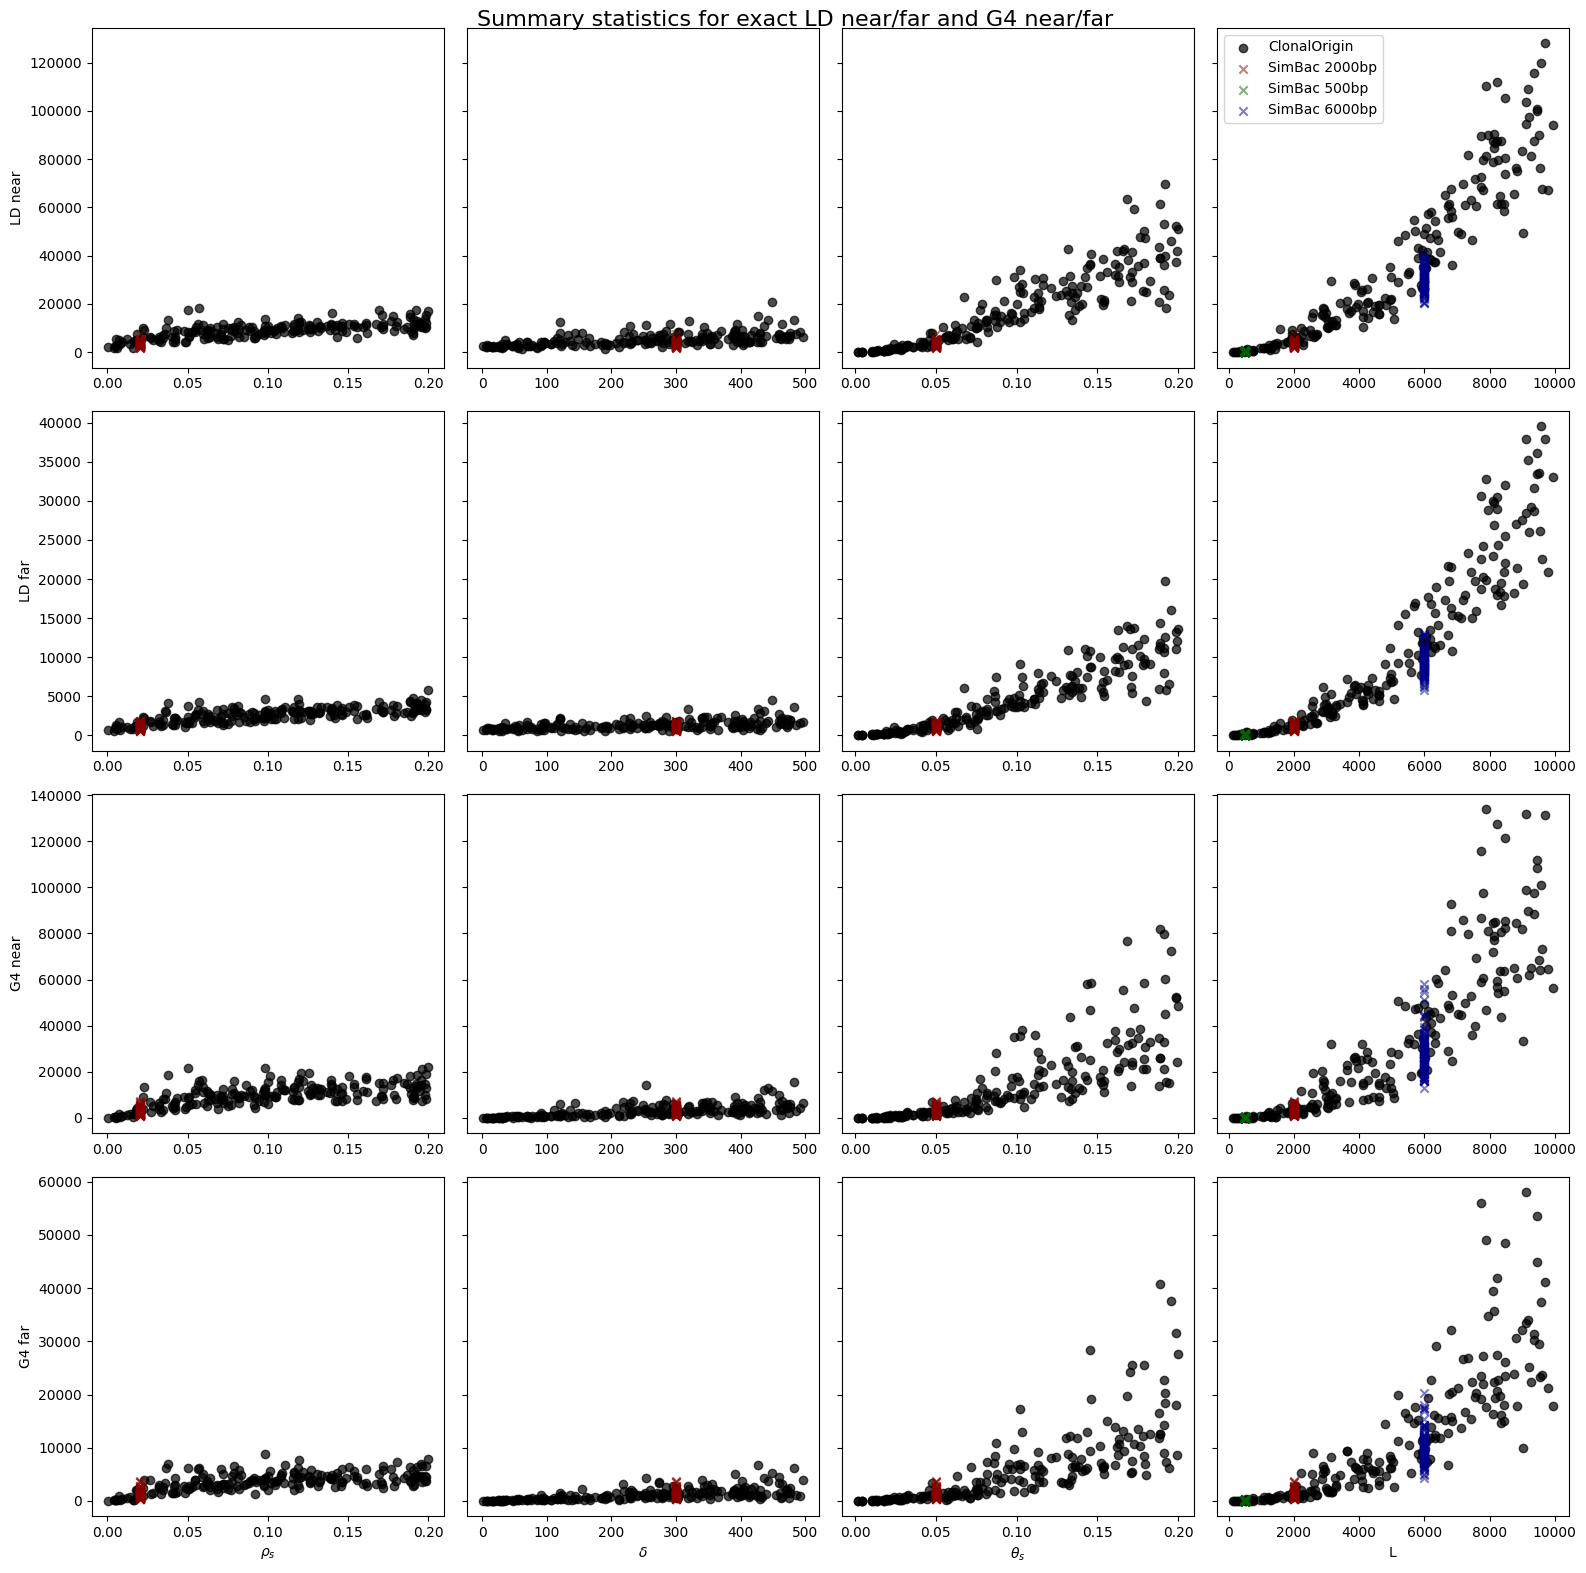

In [38]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharey='row')

x_data = [x_S[:, 0], x_S[:, 1], x_S[:, 2], x_S[:, 3]]
true_x = [0.02, 300, 0.05, 2000]
y_data_matrices = [rho_S, delta_S, theta_S, L_S]
x_labels = [r'$\rho_s$', r'$\delta$', r'$\theta_s$', "L"]

for col in range(4):
    x = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    axs[0, col].scatter(x, y_mat[:, 0], marker='o', color='black', label="ClonalOrigin", alpha=0.7)
    axs[0, col].scatter(np.full(100, fix_x), x_2000_mat[:, 0], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[1, col].scatter(x, y_mat[:, 1], marker='o', color='black', alpha=0.7)
    axs[1, col].scatter(np.full(100, fix_x), x_2000_mat[:, 1], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[2, col].scatter(x, y_mat[:, 2], marker='o', color='black', alpha=0.7)
    axs[2, col].scatter(np.full(100, fix_x), x_2000_mat[:, 2], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[3, col].scatter(x, y_mat[:, 3], marker='o', color='black', alpha=0.7)
    axs[3, col].scatter(np.full(100, fix_x), x_2000_mat[:, 3], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)
    axs[3, col].set_xlabel(x_labels[col])

    if col == 3:
        axs[0, col].scatter(np.full(100, 500), x_500_mat[:, 0], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[0, col].scatter(np.full(100, 6000), x_6000_mat[:, 0], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[1, col].scatter(np.full(100, 500), x_500_mat[:, 1], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[1, col].scatter(np.full(100, 6000), x_6000_mat[:, 1], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[2, col].scatter(np.full(100, 500), x_500_mat[:, 2], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[2, col].scatter(np.full(100, 6000), x_6000_mat[:, 2], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[3, col].scatter(np.full(100, 500), x_500_mat[:, 3], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[3, col].scatter(np.full(100, 6000), x_6000_mat[:, 3], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('LD near')
axs[1, 0].set_ylabel('LD far')
axs[2, 0].set_ylabel('G4 near')
axs[3, 0].set_ylabel('G4 far')

axs[0, 3].legend(loc='best')

plt.suptitle('Summary statistics for exact LD near/far and G4 near/far', fontsize=16)
plt.tight_layout()
plt.show()

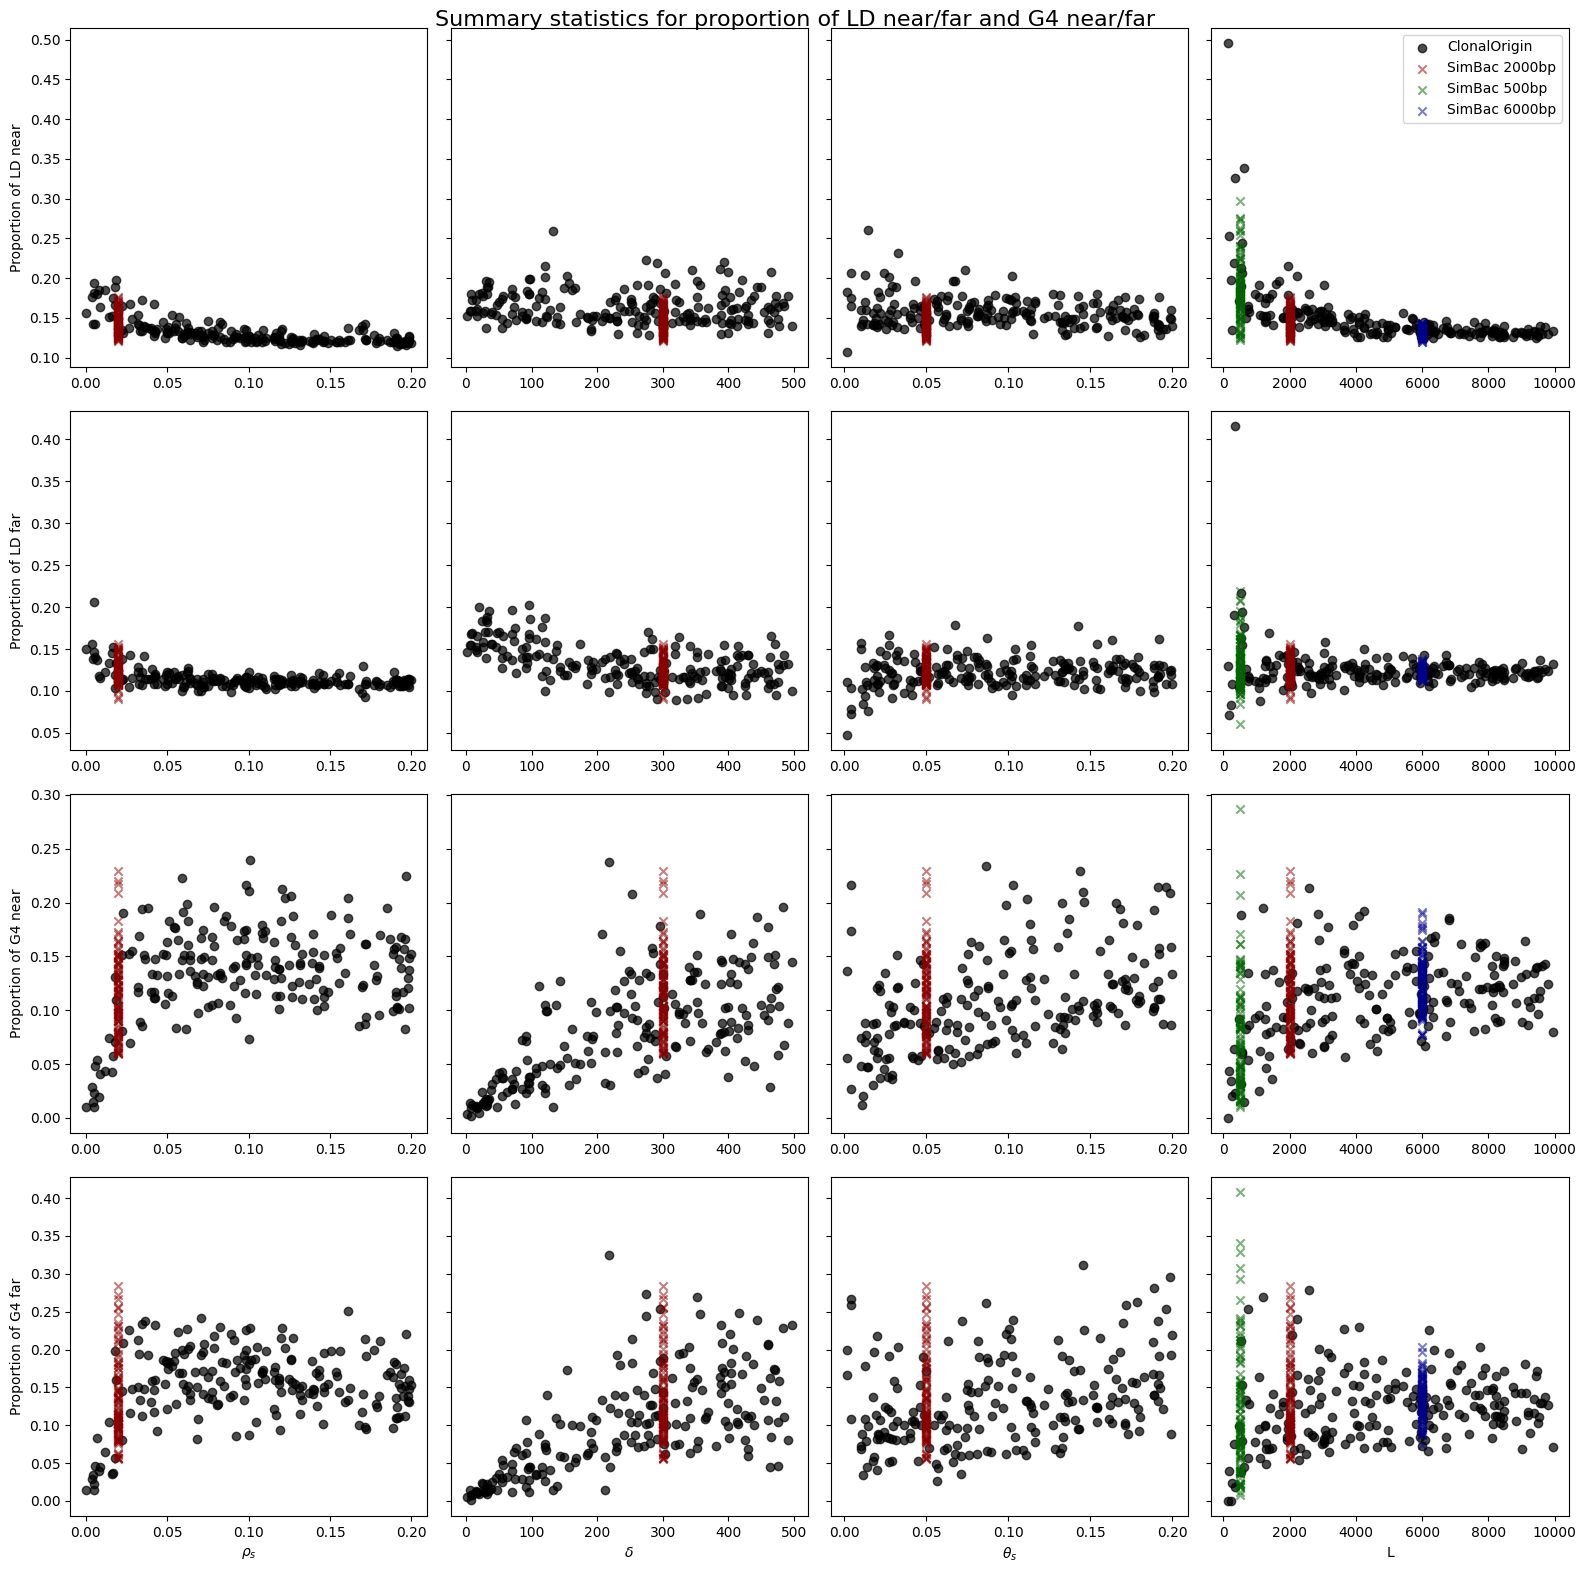

In [39]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharey='row')

x_data = [x_S[:, 0], x_S[:, 1], x_S[:, 2], x_S[:, 3]]
true_x = [0.02, 300, 0.05, 2000]
y_data_matrices = [rho_S, delta_S, theta_S, L_S]
x_labels = [r'$\rho_s$', r'$\delta$', r'$\theta_s$', "L"]

for col in range(4):
    x = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    axs[0, col].scatter(x, y_mat[:, 4], marker='o', color='black', label="ClonalOrigin", alpha=0.7)
    axs[0, col].scatter(np.full(100, fix_x), x_2000_mat[:, 4], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[1, col].scatter(x, y_mat[:, 5], marker='o', color='black', alpha=0.7)
    axs[1, col].scatter(np.full(100, fix_x), x_2000_mat[:, 5], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[2, col].scatter(x, y_mat[:, 6], marker='o', color='black', alpha=0.7)
    axs[2, col].scatter(np.full(100, fix_x), x_2000_mat[:, 6], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[3, col].scatter(x, y_mat[:, 7], marker='o', color='black', alpha=0.7)
    axs[3, col].scatter(np.full(100, fix_x), x_2000_mat[:, 7], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)
    axs[3, col].set_xlabel(x_labels[col])

    if col == 3:
        axs[0, col].scatter(np.full(100, 500), x_500_mat[:, 4], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[0, col].scatter(np.full(100, 6000), x_6000_mat[:, 4], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[1, col].scatter(np.full(100, 500), x_500_mat[:, 5], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[1, col].scatter(np.full(100, 6000), x_6000_mat[:, 5], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[2, col].scatter(np.full(100, 500), x_500_mat[:, 6], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[2, col].scatter(np.full(100, 6000), x_6000_mat[:, 6], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[3, col].scatter(np.full(100, 500), x_500_mat[:, 7], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[3, col].scatter(np.full(100, 6000), x_6000_mat[:, 7], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('Proportion of LD near')
axs[1, 0].set_ylabel('Proportion of LD far')
axs[2, 0].set_ylabel('Proportion of G4 near')
axs[3, 0].set_ylabel('Proportion of G4 far')

axs[0, 3].legend(loc='best')

plt.suptitle('Summary statistics for proportion of LD near/far and G4 near/far', fontsize=16)
plt.tight_layout()
plt.show()

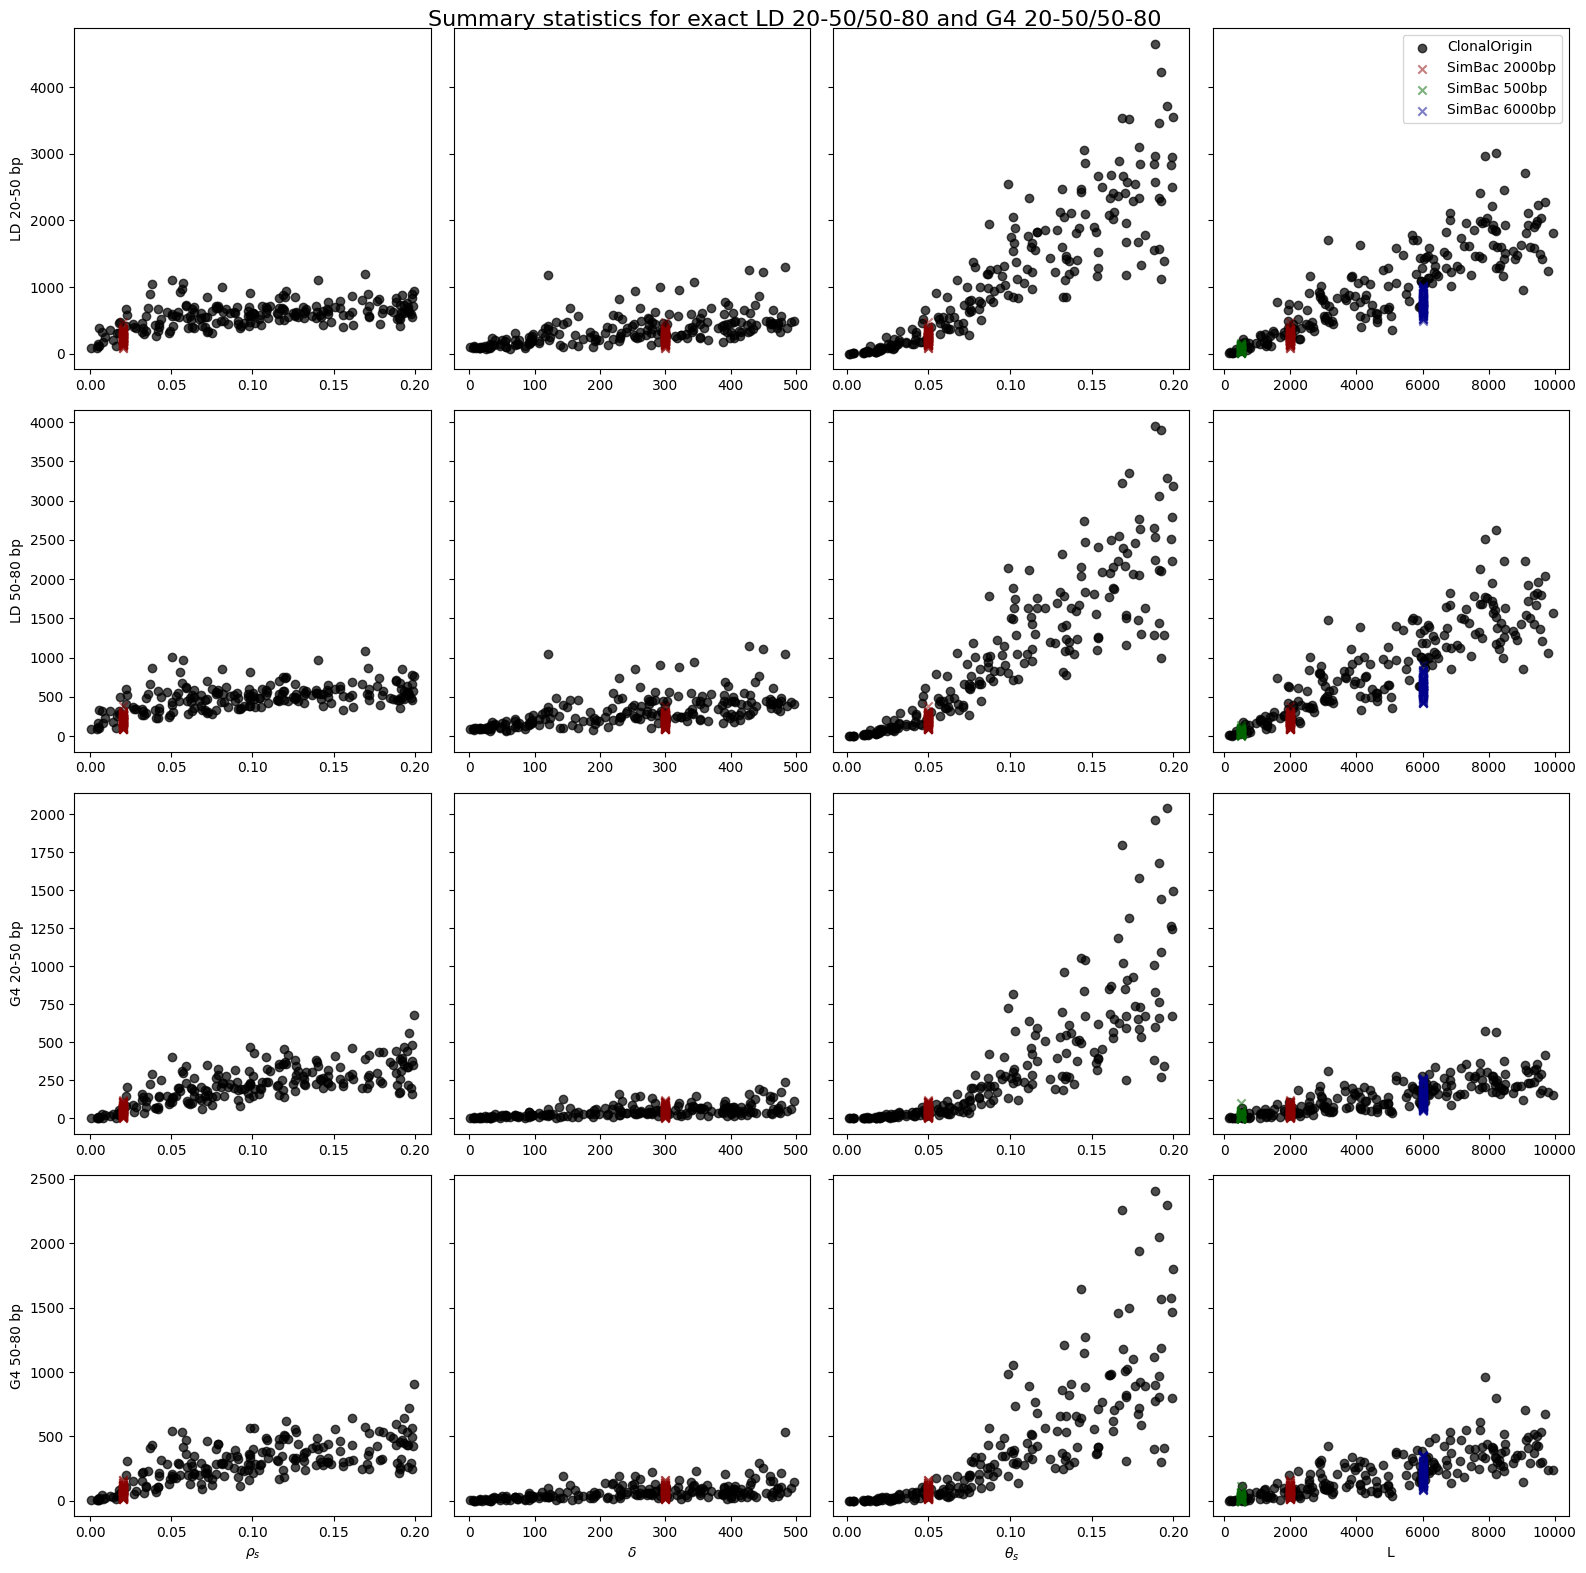

In [40]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharey='row')

x_data = [x_S[:, 0], x_S[:, 1], x_S[:, 2], x_S[:, 3]]
true_x = [0.02, 300, 0.05, 2000]
y_data_matrices = [rho_S, delta_S, theta_S, L_S]
x_labels = [r'$\rho_s$', r'$\delta$', r'$\theta_s$', "L"]

for col in range(4):
    x = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    axs[0, col].scatter(x, y_mat[:, 8], marker='o', color='black', label="ClonalOrigin", alpha=0.7)
    axs[0, col].scatter(np.full(100, fix_x), x_2000_mat[:, 8], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[1, col].scatter(x, y_mat[:, 9], marker='o', color='black', alpha=0.7)
    axs[1, col].scatter(np.full(100, fix_x), x_2000_mat[:, 9], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[2, col].scatter(x, y_mat[:, 10], marker='o', color='black', alpha=0.7)
    axs[2, col].scatter(np.full(100, fix_x), x_2000_mat[:, 10], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[3, col].scatter(x, y_mat[:, 11], marker='o', color='black', alpha=0.7)
    axs[3, col].scatter(np.full(100, fix_x), x_2000_mat[:, 11], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)
    axs[3, col].set_xlabel(x_labels[col])

    if col == 3:
        axs[0, col].scatter(np.full(100, 500), x_500_mat[:, 8], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[0, col].scatter(np.full(100, 6000), x_6000_mat[:, 8], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[1, col].scatter(np.full(100, 500), x_500_mat[:, 9], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[1, col].scatter(np.full(100, 6000), x_6000_mat[:, 9], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[2, col].scatter(np.full(100, 500), x_500_mat[:, 10], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[2, col].scatter(np.full(100, 6000), x_6000_mat[:, 10], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[3, col].scatter(np.full(100, 500), x_500_mat[:, 11], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[3, col].scatter(np.full(100, 6000), x_6000_mat[:, 11], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('LD 20-50 bp')
axs[1, 0].set_ylabel('LD 50-80 bp')
axs[2, 0].set_ylabel('G4 20-50 bp')
axs[3, 0].set_ylabel('G4 50-80 bp')

axs[0, 3].legend(loc='best')

plt.suptitle('Summary statistics for exact LD 20-50/50-80 and G4 20-50/50-80', fontsize=16)
plt.tight_layout()
plt.show()

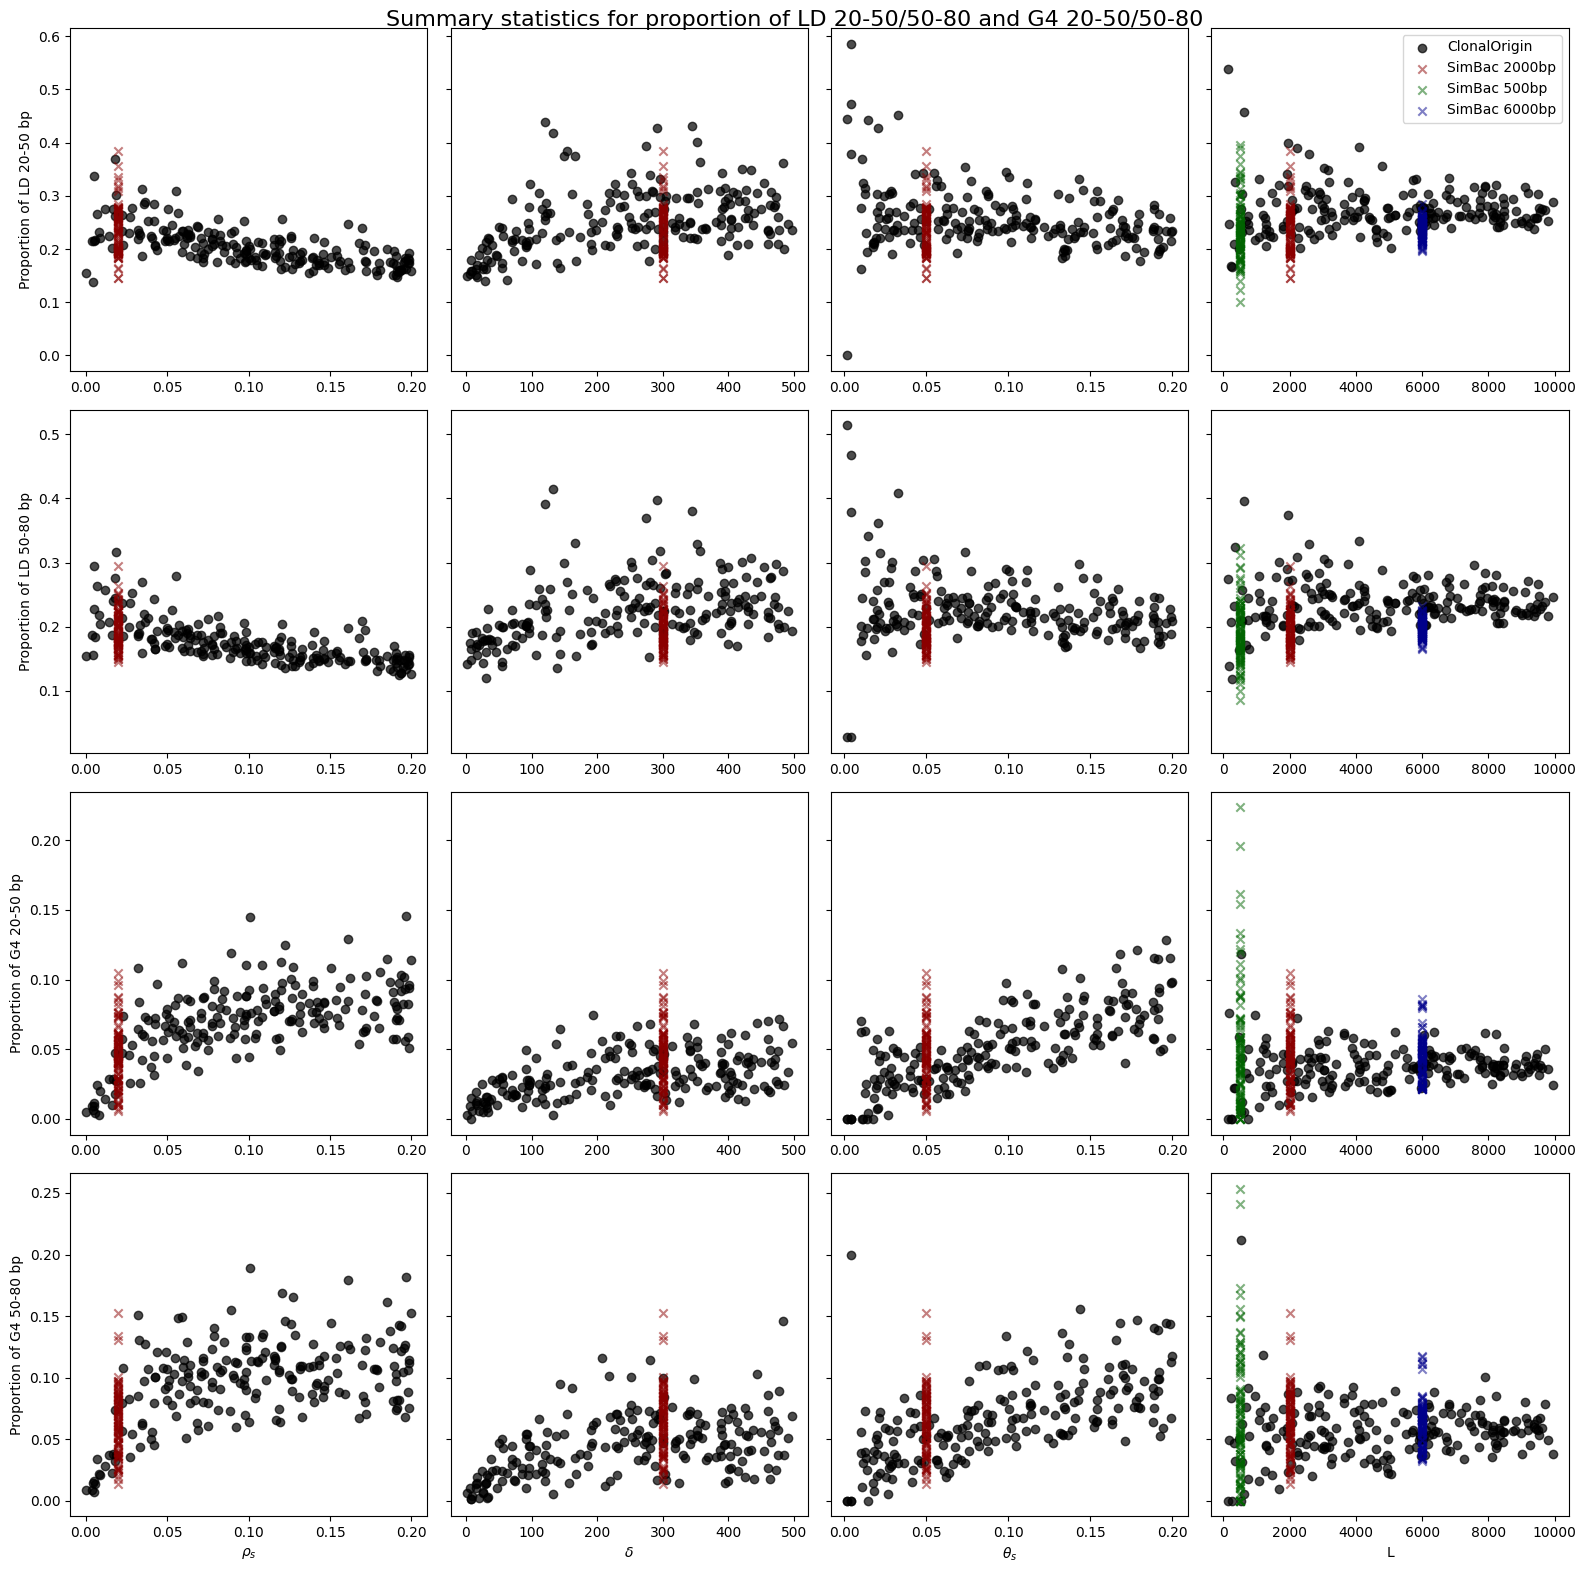

In [41]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16), sharey='row')

x_data = [x_S[:, 0], x_S[:, 1], x_S[:, 2], x_S[:, 3]]
true_x = [0.02, 300, 0.05, 2000]
y_data_matrices = [rho_S, delta_S, theta_S, L_S]
x_labels = [r'$\rho_s$', r'$\delta$', r'$\theta_s$', "L"]

for col in range(4):
    x = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    axs[0, col].scatter(x, y_mat[:, 12], marker='o', color='black', label="ClonalOrigin", alpha=0.7)
    axs[0, col].scatter(np.full(100, fix_x), x_2000_mat[:, 12], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[1, col].scatter(x, y_mat[:, 13], marker='o', color='black', alpha=0.7)
    axs[1, col].scatter(np.full(100, fix_x), x_2000_mat[:, 13], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[2, col].scatter(x, y_mat[:, 14], marker='o', color='black', alpha=0.7)
    axs[2, col].scatter(np.full(100, fix_x), x_2000_mat[:, 14], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[3, col].scatter(x, y_mat[:, 15], marker='o', color='black', alpha=0.7)
    axs[3, col].scatter(np.full(100, fix_x), x_2000_mat[:, 15], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)
    axs[3, col].set_xlabel(x_labels[col])

    if col == 3:
        axs[0, col].scatter(np.full(100, 500), x_500_mat[:, 12], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[0, col].scatter(np.full(100, 6000), x_6000_mat[:, 12], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[1, col].scatter(np.full(100, 500), x_500_mat[:, 13], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[1, col].scatter(np.full(100, 6000), x_6000_mat[:, 13], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[2, col].scatter(np.full(100, 500), x_500_mat[:, 14], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[2, col].scatter(np.full(100, 6000), x_6000_mat[:, 14], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[3, col].scatter(np.full(100, 500), x_500_mat[:, 15], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[3, col].scatter(np.full(100, 6000), x_6000_mat[:, 15], marker='x', color='darkblue', label = "SimBac 600０bp", alpha=0.5)

axs[0, 0].set_ylabel('Proportion of LD 20-50 bp')
axs[1, 0].set_ylabel('Proportion of LD 50-80 bp')
axs[2, 0].set_ylabel('Proportion of G4 20-50 bp')
axs[3, 0].set_ylabel('Proportion of G4 50-80 bp')

axs[0, 3].legend(loc='best')

plt.suptitle('Summary statistics for proportion of LD 20-50/50-80 and G4 20-50/50-80', fontsize=16)
plt.tight_layout()
plt.show()

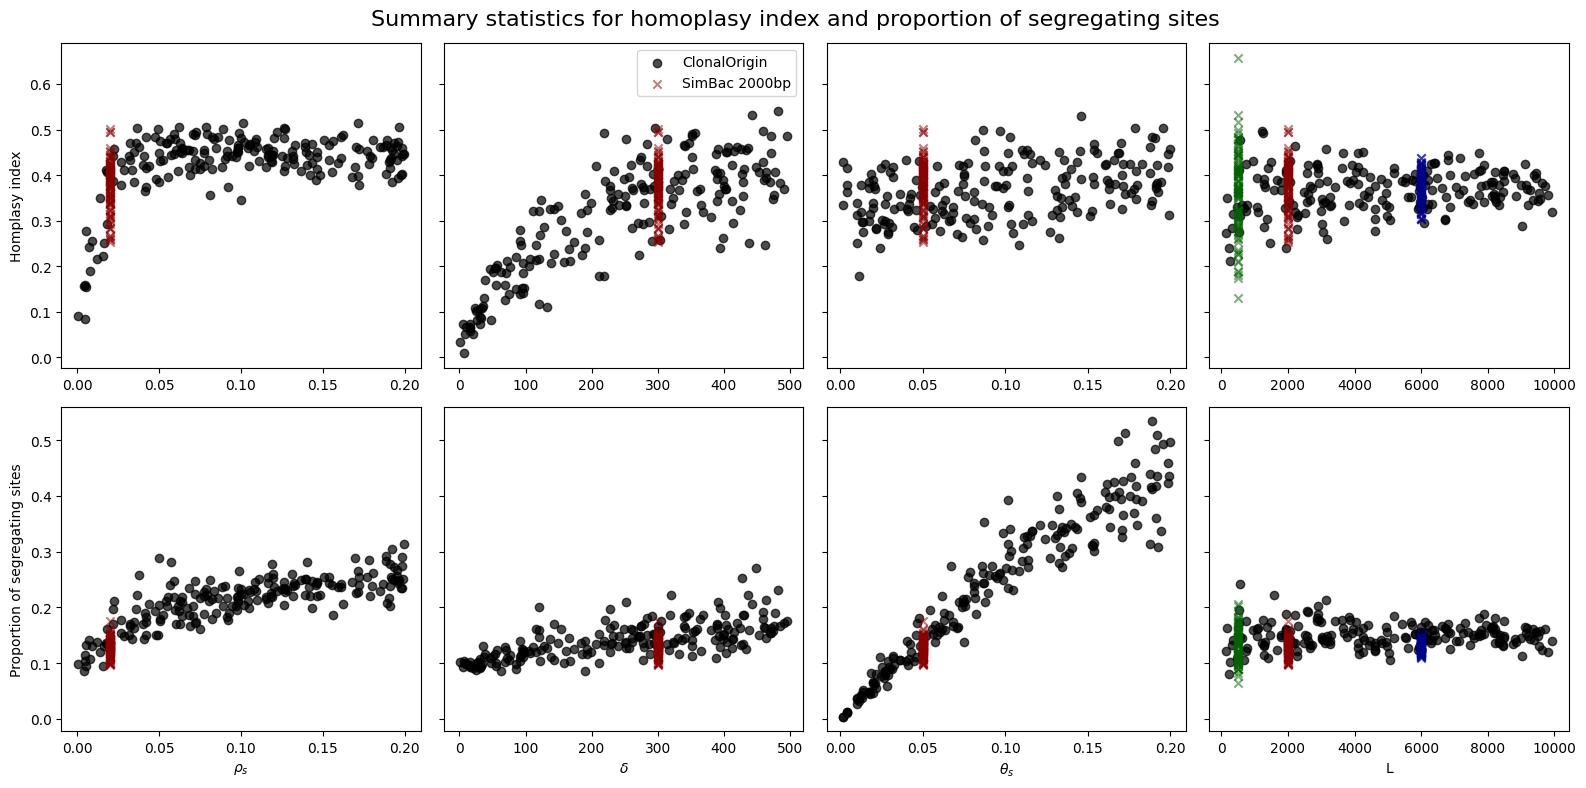

In [43]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8), sharey='row')

x_data = [x_S[:, 0], x_S[:, 1], x_S[:, 2], x_S[:, 3]]
true_x = [0.02, 300, 0.05, 2000]
y_data_matrices = [rho_S, delta_S, theta_S, L_S]
x_labels = [r'$\rho_s$', r'$\delta$', r'$\theta_s$', "L"]

for col in range(4):
    x = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    axs[0, col].scatter(x, y_mat[:, 16], marker='o', color='black', label="ClonalOrigin", alpha=0.7)
    axs[0, col].scatter(np.full(100, fix_x), x_2000_mat[:, 16], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[1, col].scatter(x, y_mat[:, 17], marker='o', color='black', alpha=0.7)
    axs[1, col].scatter(np.full(100, fix_x), x_2000_mat[:, 17], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)
    axs[1, col].set_xlabel(x_labels[col])

    if col == 3:
        axs[0, col].scatter(np.full(100, 500), x_500_mat[:, 16], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[0, col].scatter(np.full(100, 6000), x_6000_mat[:, 16], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

        axs[1, col].scatter(np.full(100, 500), x_500_mat[:, 17], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
        axs[1, col].scatter(np.full(100, 6000), x_6000_mat[:, 17], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('Homplasy index')
axs[1, 0].set_ylabel('Proportion of segregating sites')

axs[0, 1].legend(loc='best')

plt.suptitle('Summary statistics for homoplasy index and proportion of segregating sites', fontsize=16)
plt.tight_layout()
plt.show()